In [1]:
print("ram ram")

ram ram


In [3]:
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'Tally ODBC Driver64', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [5]:
import os
import urllib.parse
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Load environment variables from .env file
load_dotenv()

# Read DB parameters from environment variables
DB_DRIVER = os.getenv("DB_DRIVER", "ODBC Driver 18 for SQL Server")
DB_SERVER = os.getenv("DB_SERVER", "localhost")
DB_NAME = os.getenv("DB_NAME", "mes_new")
DB_TRUSTED_CONNECTION = os.getenv("DB_TRUSTED_CONNECTION", "yes")
DB_ENCRYPT = os.getenv("DB_ENCRYPT", "yes")
DB_TRUST_SERVER_CERTIFICATE = os.getenv("DB_TRUST_SERVER_CERTIFICATE", "yes")

# Construct ODBC Connection String safely
odbc_str = (
    f"DRIVER={{{DB_DRIVER}}};"
    f"SERVER={DB_SERVER};"
    f"DATABASE={DB_NAME};"
    f"Trusted_Connection={DB_TRUSTED_CONNECTION};"
    f"Encrypt={DB_ENCRYPT};"
    f"TrustServerCertificate={DB_TRUST_SERVER_CERTIFICATE};"
)

# Encode params for SQLAlchemy engine URL
params = urllib.parse.quote_plus(odbc_str)
DATABASE_URL = f"mssql+pyodbc:///?odbc_connect={params}"

# Initialize Engine
engine = create_engine(DATABASE_URL)

# Test Connection
try:
    with engine.connect() as conn:
        print(f"Connected successfully to {DB_NAME}!")
        result = conn.exec_driver_sql("SELECT @@VERSION").fetchone()
        print(result[0])
except Exception as e:
    print("Connection failed:", e)

Connected successfully to mes_new!
Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) 
	Oct  8 2022 05:58:25 
	Copyright (C) 2022 Microsoft Corporation
	Enterprise Evaluation Edition (64-bit) on Windows 10 Home Single Language 10.0 <X64> (Build 26200: ) (Hypervisor)



In [ ]:
import os
import urllib.parse
from typing import TypedDict, Dict, Any, List
from datetime import datetime
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# LangChain & LangGraph Imports
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END

# =====================================================================
# 0. CONFIGURATION & ENGINE SETUP
# =====================================================================
load_dotenv()

# Read DB parameters
DB_DRIVER = os.getenv("DB_DRIVER", "ODBC Driver 18 for SQL Server")
DB_SERVER = os.getenv("DB_SERVER", "localhost")
DB_NAME = os.getenv("DB_NAME", "mes_new")
DB_TRUSTED_CONNECTION = os.getenv("DB_TRUSTED_CONNECTION", "yes")
DB_ENCRYPT = os.getenv("DB_ENCRYPT", "yes")
DB_TRUST_SERVER_CERTIFICATE = os.getenv("DB_TRUST_SERVER_CERTIFICATE", "yes")

# Database Engine
odbc_str = (
    f"DRIVER={{{DB_DRIVER}}};"
    f"SERVER={DB_SERVER};"
    f"DATABASE={DB_NAME};"
    f"Trusted_Connection={DB_TRUSTED_CONNECTION};"
    f"Encrypt={DB_ENCRYPT};"
    f"TrustServerCertificate={DB_TRUST_SERVER_CERTIFICATE};"
)
params = urllib.parse.quote_plus(odbc_str)
DATABASE_URL = f"mssql+pyodbc:///?odbc_connect={params}"
engine = create_engine(DATABASE_URL)

# --- LLM Factory Function ---
def get_llm(provider: str = "gemini"):
    """
    Returns an LLM instance based on the provider choice: 'gemini' or 'groq'.
    """
    provider = provider.lower()
    
    if provider == "gemini":
        api_key = os.getenv("GEMINI_API_KEY")
        if not api_key:
            raise ValueError("GEMINI_API_KEY is missing from environment variables.")
        return ChatGoogleGenerativeAI(
            model="gemini-3.5-flash-lite",
            google_api_key=api_key,
            temperature=0
        )
        
    elif provider == "groq":
        api_key = os.getenv("GROQ_API_KEY")
        if not api_key:
            raise ValueError("GROQ_API_KEY is missing from environment variables.")
        return ChatGroq(
            model="llama-3.3-70b-versatile",
            groq_api_key=api_key,
            temperature=0
        )
    else:
        raise ValueError(f"Unsupported provider: '{provider}'. Choose 'gemini' or 'groq'.")


# =====================================================================
# 1. STATE DEFINITION
# =====================================================================
class AgentState(TypedDict):
    task: str                         
    schema_mapping: Dict[str, Any]    
    raw_tables_metadata: str          
    canonical_query: str              
    generated_sql: str                
    query_results: List[Dict]         
    insight: str                      
    requires_approval: bool           
    proposed_action: Dict[str, Any]   
    approval_status: str              


# =====================================================================
# 2. CORE AGENT NODES
# =====================================================================

def introspect_schema_node(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: Schema Introspection & Resolution] ---")
    
    introspection_query = """
    SELECT TABLE_SCHEMA, TABLE_NAME, COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_SCHEMA = 'dbo'
    ORDER BY TABLE_NAME, ORDINAL_POSITION;
    """
    
    metadata_lines = []
    try:
        with engine.connect() as conn:
            df = pd.read_sql(text(introspection_query), conn)
            
            for table_name, group in df.groupby('TABLE_NAME'):
                cols = ", ".join([f"{row['COLUMN_NAME']} {row['DATA_TYPE']}" for _, row in group.iterrows()])
                metadata_lines.append(f"- Table: dbo.{table_name} ({cols})")
                
        raw_metadata = "\n".join(metadata_lines)
    except Exception as e:
        print(f"⚠️ Dynamic introspection failed: {e}")
        raw_metadata = "Database connection error during introspection."

    resolved_mapping = {
        "canonical_machines": "dbo.MachineMaster",
        "canonical_orders": "dbo.WorkOrder",
        "canonical_capacity": "dbo.CapacityAnalysis",
        "canonical_alerts": "dbo.AlertMaster",
        "canonical_wip_requests": "dbo.WIPRMRequest"
    }
    
    return {
        "raw_tables_metadata": raw_metadata,
        "schema_mapping": resolved_mapping
    }


def query_generator_node(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: Dynamic SQL Generation] ---")
    
    # Select provider from .env (defaults to gemini)
    provider = os.getenv("SQL_GENERATOR_PROVIDER", "gemini")
    llm = get_llm(provider=provider)
    print(f"Using Provider: [{provider.upper()}] for SQL Generation")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a senior Manufacturing Data Engineer. 
        Your task is to write a read-only T-SQL query for Microsoft SQL Server to extract operational data.
        
        CRITICAL RULES:
        - Do NOT invent tables or columns. Use ONLY the tables and columns listed in the schema metadata.
        - Map canonical terms to their raw table names using the Mapping Dictionary.
        - Return ONLY raw executable T-SQL query without markdown formatting or backticks.
        
        Connected MES Database Schema:
        {metadata}
        
        Canonical -> Raw Mapping Dictionary:
        {mapping}"""),
        ("human", "Generate a SQL query to satisfy this operational request: '{task}'")
    ])
    
    chain = prompt | llm
    response = chain.invoke({
        "metadata": state["raw_tables_metadata"],
        "mapping": state["schema_mapping"],
        "task": state["task"]
    })
    
    # Handle response content safely regardless of whether it's a str or a list
    if isinstance(response.content, list):
        # Extract text from content block dictionary if returned as a list
        raw_text = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part) 
            for part in response.content
        )
    else:
        raw_text = response.content

    # Clean code fences
    clean_sql = raw_text.replace("```sql", "").replace("```", "").strip()
    print(f"Generated SQL for target database:\n{clean_sql}\n")
    
    return {"generated_sql": clean_sql}

def db_executor_node(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: DB Executor] ---")
    print(f"Executing Query against {DB_NAME}: {state['generated_sql']}")
    
    results = []
    try:
        with engine.connect() as conn:
            df = pd.read_sql(text(state['generated_sql']), conn)
            results = df.to_dict(orient="records")
            print(f"Query returned {len(results)} rows.\n")
    except Exception as e:
        print(f"❌ SQL Execution Error: {e}")
        results = [{"error": str(e)}]
        
    return {"query_results": results}


def operations_analyst_node(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: Operations & Maintenance Analyst] ---")
    
    # Select provider from .env (defaults to groq)
    provider = os.getenv("ANALYST_PROVIDER", "groq")
    llm = get_llm(provider=provider)
    print(f"Using Provider: [{provider.upper()}] for Operations Analysis")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are the AI Operations & Maintenance Agent. Assess this live MES telemetry. "
                   "If any anomaly, error, or low performance is found, flag it and propose a resolution action "
                   "formatted strictly as a JSON block with keys: 'requires_escalation' (bool), 'proposed_action' (str), 'reason' (str)."),
        ("human", "MES Query Results:\n{results}")
    ])
    
    chain = prompt | llm | JsonOutputParser()
    analysis = chain.invoke({"results": state["query_results"]})
    
    print(f"Agent Evaluation Result:\n{analysis}\n")
    
    return {
        "insight": analysis.get("reason", "Operations steady."),
        "requires_approval": analysis.get("requires_escalation", False),
        "proposed_action": {
            "action": analysis.get("proposed_action", ""),
            "target_system": DB_NAME
        },
        "approval_status": "Pending" if analysis.get("requires_escalation", False) else "Auto-Approved"
    }


def human_approval_gate(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: Human Approval Gate Check] ---")
    if state["requires_approval"]:
        print(f"⚠️ Escalating proposed action for user review: {state['proposed_action']['action']}")
        user_response = input("Approve this action? (yes/no/edit): ")
        if user_response.lower() in ["yes", "y"]:
            return {"approval_status": "Approved"}
        else:
            return {"approval_status": "Rejected"}
    return {"approval_status": "Auto-Approved"}

def write_back_node(state: AgentState) -> Dict[str, Any]:
    print("--- [Node: MES Database Write-back] ---")
    if state["approval_status"] == "Approved":
        # Updated SQL to include the required 'AlertType' column
        write_sql = """
        IF EXISTS (SELECT * FROM sys.tables WHERE name = 'AlertMaster')
        BEGIN
            INSERT INTO dbo.AlertMaster (AlertType, Severity, IsResolved, CreatedDate) 
            VALUES ('Anomaly', 'Critical', 0, GETUTCDATE());
        END
        """
        try:
            with engine.begin() as conn:
                conn.execute(text(write_sql))
            print(f"Action Committed successfully to database [{DB_NAME}]!")
        except Exception as e:
            print(f"❌ Failed to commit write-back action: {e}")
    else:
        print("Action declined or skipped.")
    return {}

# =====================================================================
# 3. BUILD THE STATE GRAPH
# =====================================================================

workflow = StateGraph(AgentState)

# Define Nodes
workflow.add_node("introspect", introspect_schema_node)
workflow.add_node("generate_sql", query_generator_node)
workflow.add_node("execute_query", db_executor_node)
workflow.add_node("analyze", operations_analyst_node)
workflow.add_node("approval_gate", human_approval_gate)
workflow.add_node("write_back", write_back_node)

# Set Entry Point
workflow.set_entry_point("introspect")

# Define Edges
workflow.add_edge("introspect", "generate_sql")
workflow.add_edge("generate_sql", "execute_query")
workflow.add_edge("execute_query", "analyze")
workflow.add_edge("analyze", "approval_gate")

def route_approval(state: AgentState) -> str:
    if state["approval_status"] in ["Approved", "Auto-Approved"]:
        return "write_back"
    return END

workflow.add_conditional_edges(
    "approval_gate",
    route_approval,
    {
        "write_back": "write_back",
        END: END
    }
)

workflow.add_edge("write_back", END)

app = workflow.compile()

# =====================================================================
# 4. EXECUTION
# =====================================================================
if __name__ == "__main__":
    initial_state = {
        "task": "Show all pending WIP raw material requests in the store",
        "schema_mapping": {},
        "raw_tables_metadata": "",
        "canonical_query": "",
        "generated_sql": "",
        "query_results": [],
        "insight": "",
        "requires_approval": False,
        "proposed_action": {},
        "approval_status": "Pending"
    }

    output = app.invoke(initial_state)

--- [Node: Schema Introspection & Resolution] ---
--- [Node: Dynamic SQL Generation] ---
Using Provider: [GEMINI] for SQL Generation
Generated SQL for target database:
SELECT Id, RequestId, ItemCode, RequestedQuantity, UOM, ReleasedQuantity, ReceivedQuantity, StoreId, StoreName, Status, CreatedBy, CreatedOn
FROM dbo.WIPRMRequest
WHERE Status = 'Pending'

--- [Node: DB Executor] ---
Executing Query against mes_new: SELECT Id, RequestId, ItemCode, RequestedQuantity, UOM, ReleasedQuantity, ReceivedQuantity, StoreId, StoreName, Status, CreatedBy, CreatedOn
FROM dbo.WIPRMRequest
WHERE Status = 'Pending'
Query returned 2 rows.

--- [Node: Operations & Maintenance Analyst] ---
Using Provider: [GROQ] for Operations Analysis
Agent Evaluation Result:
{'requires_escalation': True, 'proposed_action': 'Investigate and resolve the delay in releasing and receiving items for the pending requests WIP00002 and WIP00004', 'reason': "The requests have been in a 'Pending' status for an extended period with

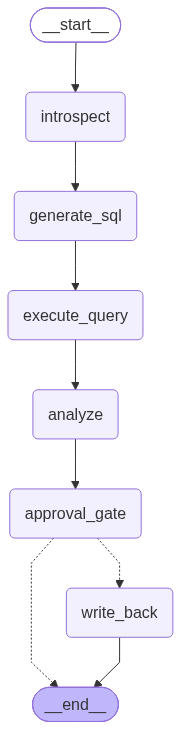

In [6]:
app